## Projeto do Bootcamp Avanti - Machine Learning

🔹 Projeto 03

📌 Assunto: Classificação de lesões em folhas de feijão

🔗 Dataset: https://www.kaggle.com/datasets/marquis03/bean-leaf-lesions-classification


### Participantes:
Cristiane Santos da Cunha

Dayna Lilian Figueiredo

Eric Gabriel Aguiar de Alencar

Fabrício Almeida Santos

Ian Silva Nogueira

Jaime Teixeira de Araújo Júnior

Juliana Gonçalves Câmara

### ATIVIDADE-04-ETAPA-01
#### Objetivo: Apresentar informações do dataset





#### Baixar dataset do Kaggle

In [2]:
!pip install opendatasets
!pip install pandas
!pip install imagehash

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.7/296.7 kB 6.0 MB/s eta 0:00:00


In [4]:
import opendatasets as od
import pandas as pd

dataset_path = od.download("https://www.kaggle.com/datasets/marquis03/bean-leaf-lesions-classification")

Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: eng.criscunha
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/marquis03/bean-leaf-lesions-classification


100%|██████████| 155M/155M [00:01<00:00, 127MB/s]


In [ ]:
# IMPORTAÇÕES

import pandas as pd
import os

import cv2
import imagehash
import matplotlib.pyplot as plt
%matplotlib inline
import random
import shutil


In [5]:
!ls

bean-leaf-lesions-classification  sample_data


### Criar um Dataframe com os metadados das imagens

In [7]:
root_dir = './bean-leaf-lesions-classification/train'

In [8]:
from PIL import Image
count_corrupted = 0
corrupted = list()

In [9]:
dataframe_list = list()
for folder in os.listdir(root_dir):
  child_dir = os.path.join(root_dir, folder)

  for image in os.listdir(child_dir):
    img_dir = os.path.join(child_dir, image)
    _, image_format = image.rsplit('.', 1)
    image_format = image_format.lower()
    img = cv2.imread(img_dir)


    if img is not None:
      img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
      # Converter a imagem OpenCV para uma imagem do Pillow
      img_pil = Image.fromarray(img_rgb)

      # Gerar o hash da imagem (usando perceptual hash como exemplo)
      img_hash = imagehash.phash(img_pil)
      width, height, channels = img.shape
      img_corrupted = False
    else:
      count_corrupted += 1
      corrupted.append(img_dir)
      img_corrupted = True
      img_hash, image_format, width, height, channels = None, None, None, None, None

    dataframe_list.append([img_dir, img_corrupted, img_hash, image_format, width, height, channels, folder])

### Integridade dos Arquivos

In [10]:
print(f'Total de Imagens Corrompidas: {count_corrupted}\nImagens corrompidas {corrupted}')

Total de Imagens Corrompidas: 1
Imagens corrompidas ['./bean-leaf-lesions-classification/train/healthy/healthy_train.120tore']


In [11]:
if os.path.exists(corrupted[0]):
    os.remove(corrupted[0])
else:
    print(f"O arquivo {corrupted[0]} não foi encontrado. Pode já ter sido removido ou não existe.")

In [12]:
print(os.path.exists(corrupted[0]))

False


#### Separação das imagens para treinamento, teste e validação


In [13]:
# estrutura do data set

print(os.listdir("./bean-leaf-lesions-classification"))

['train.csv', 'val', 'val.csv', 'classname.txt', 'train']


In [15]:
# Caminhos
train_dir = "./bean-leaf-lesions-classification/train"
test_dir = "./bean-leaf-lesions-classification/test"

# Cria a pasta de teste
os.makedirs(test_dir, exist_ok=True)

# Percorre cada classe
for classe in os.listdir(train_dir):

    pasta_train = os.path.join(train_dir, classe)
    pasta_test = os.path.join(test_dir, classe)

    os.makedirs(pasta_test, exist_ok=True)

    imagens = os.listdir(pasta_train)

    # Embaralha as imagens
    random.shuffle(imagens)

    # Seleciona 15%
    qtd_teste = int(len(imagens) * 0.15)

    imagens_teste = imagens[:qtd_teste]

    # Move as imagens para a pasta de teste
    for imagem in imagens_teste:
        origem = os.path.join(pasta_train, imagem)
        destino = os.path.join(pasta_test, imagem)
        shutil.move(origem, destino)

print("Conjunto de teste criado com sucesso!")

Conjunto de teste criado com sucesso!


In [16]:
train_df = pd.read_csv("./bean-leaf-lesions-classification/train.csv")

train_df.head()

,image:FILE,category
0,train/healthy/healthy_train.98.jpg,0
1,train/healthy/healthy_train.148.jpg,0
2,train/healthy/healthy_train.306.jpg,0
3,train/healthy/healthy_train.305.jpg,0
4,train/healthy/healthy_train.40.jpg,0


In [20]:
print(train_df.columns)

Index(['image:FILE', 'category'], dtype='object')


In [18]:
# Ler o CSV
train_df = pd.read_csv("./bean-leaf-lesions-classification/train.csv")

# Imagens listadas no CSV
imagens_csv = set(train_df["image:FILE"])

# Imagens existentes na pasta
imagens_pasta = set()

train_dir = "./bean-leaf-lesions-classification/train"

for classe in os.listdir(train_dir):
    pasta = os.path.join(train_dir, classe)

    if os.path.isdir(pasta):
        for img in os.listdir(pasta):
            imagens_pasta.add(img)

# Comparação
faltando = imagens_csv - imagens_pasta
extras = imagens_pasta - imagens_csv

print(f"Imagens listadas no CSV: {len(imagens_csv)}")
print(f"Imagens encontradas na pasta: {len(imagens_pasta)}")
print(f"Imagens no CSV e ausentes na pasta: {len(faltando)}")
print(f"Imagens na pasta e ausentes no CSV: {len(extras)}")

Imagens listadas no CSV: 1034
Imagens encontradas na pasta: 880
Imagens no CSV e ausentes na pasta: 1034
Imagens na pasta e ausentes no CSV: 880


In [21]:
# Validação

val_df = pd.read_csv("./bean-leaf-lesions-classification/val.csv")

imagens_csv = set(val_df["image:FILE"])
imagens_pasta = set()

val_dir = "./bean-leaf-lesions-classification/val"

for classe in os.listdir(val_dir):
    pasta = os.path.join(val_dir, classe)

    if os.path.isdir(pasta):
        for img in os.listdir(pasta):
            imagens_pasta.add(img)

faltando = imagens_csv - imagens_pasta
extras = imagens_pasta - imagens_csv

print(f"Imagens listadas no CSV: {len(imagens_csv)}")
print(f"Imagens encontradas na pasta: {len(imagens_pasta)}")
print(f"Imagens no CSV e ausentes na pasta: {len(faltando)}")
print(f"Imagens na pasta e ausentes no CSV: {len(extras)}")

Imagens listadas no CSV: 133
Imagens encontradas na pasta: 133
Imagens no CSV e ausentes na pasta: 133
Imagens na pasta e ausentes no CSV: 133


In [22]:
# Teste

# Pasta de teste
test_dir = "./bean-leaf-lesions-classification/test"

# Conjunto para armazenar os nomes das imagens
imagens_teste = set()

# Percorre cada classe
for classe in os.listdir(test_dir):
    pasta = os.path.join(test_dir, classe)

    if os.path.isdir(pasta):
        for img in os.listdir(pasta):
            imagens_teste.add(img)

print(f"Total de imagens de teste: {len(imagens_teste)}")

# Exibe algumas imagens
print("\nPrimeiras 10 imagens:")
for img in list(imagens_teste)[:10]:
    print(img)

Total de imagens de teste: 154

Primeiras 10 imagens:
angular_leaf_spot_train.281.jpg
healthy_train.306.jpg
bean_rust_train.274.jpg
healthy_train.261.jpg
healthy_train.146.jpg
bean_rust_train.290.jpg
healthy_train.165.jpg
angular_leaf_spot_train.181.jpg
bean_rust_train.18.jpg
bean_rust_train.74.jpg


In [35]:
df = pd.DataFrame(columns=['image_path', 'corrupted', 'image_hash', 'image_format', 'width', 'height', 'channels', 'label'], data = dataframe_list)

In [32]:
df.head()

,image_path,corrupted,image_hash,image_format,width,height,channels,label
0,./bean-leaf-lesions-classification/train/bean_...,False,c9f2710726c9e0bd,jpg,500.0,500.0,3.0,bean_rust
1,./bean-leaf-lesions-classification/train/bean_...,False,96a9709c27df3186,jpg,500.0,500.0,3.0,bean_rust
2,./bean-leaf-lesions-classification/train/bean_...,False,8ce63716673719d0,jpg,500.0,500.0,3.0,bean_rust
3,./bean-leaf-lesions-classification/train/bean_...,False,8517353467b14be5,jpg,500.0,500.0,3.0,bean_rust
4,./bean-leaf-lesions-classification/train/bean_...,False,95c47b1d52e1ea0b,jpg,500.0,500.0,3.0,bean_rust


In [31]:
#Informações estatísticas dos valores de altura, largura e canais das imagens

df.describe().loc[['mean', 'std', 'min', 'max']]

,width,height,channels
mean,500.0,500.0,3.0
std,0.0,0.0,0.0
min,500.0,500.0,3.0
max,500.0,500.0,3.0


In [37]:
train_dir = "./bean-leaf-lesions-classification/train"
validation_dir = "./bean-leaf-lesions-classification/val"
test_dir = "./bean-leaf-lesions-classification/test"

def contar_imagens(diretorio):
    total = 0

    for classe in os.listdir(diretorio):
        pasta = os.path.join(diretorio, classe)

        if os.path.isdir(pasta):
            total += len(os.listdir(pasta))

    return total

train = contar_imagens(train_dir)
validation = contar_imagens(val_dir)
test = contar_imagens(test_dir)

print(f"Treinamento: {train}")
print(f"Validação: {validation}")
print(f"Teste: {test}")

Treinamento: 880
Validação: 133
Teste: 154


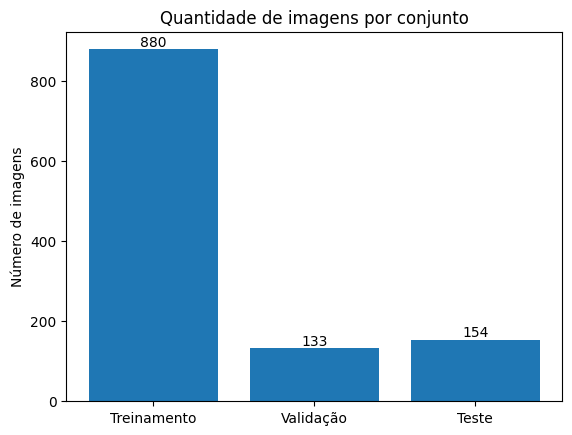

In [39]:
# Gráfico
conjuntos = ["Treinamento", "Validação", "Teste"]
quantidades = [train, validation, test]

ax = plt.bar(conjuntos, quantidades)

plt.title("Quantidade de imagens por conjunto")
plt.ylabel("Número de imagens")

for barra in ax:
    altura = barra.get_height()
    plt.text(
        barra.get_x() + barra.get_width()/2,
        altura,
        str(int(altura)),
        ha='center',
        va='bottom'
    )

plt.show()

#### Verificar se todas as imagens estão no mesmo formato

In [24]:
import os
from collections import Counter

root = "./bean-leaf-lesions-classification"

formatos = []

# Percorre todas as pastas do dataset
for conjunto in ["train", "val", "test"]:
    pasta_conjunto = os.path.join(root, conjunto)

    for classe in os.listdir(pasta_conjunto):
        pasta_classe = os.path.join(pasta_conjunto, classe)

        if not os.path.isdir(pasta_classe):
            continue

        for arquivo in os.listdir(pasta_classe):
            extensao = os.path.splitext(arquivo)[1].lower()
            formatos.append(extensao)

# Conta quantos arquivos existem de cada formato
contagem = Counter(formatos)

print("Formatos encontrados:")
for formato, quantidade in contagem.items():
    print(f"{formato}: {quantidade} imagens")

Formatos encontrados:
.jpg: 1167 imagens


In [42]:
# Tipos de imagens
pastas = {
    "Treinamento": "./bean-leaf-lesions-classification/train",
    "Validação": "./bean-leaf-lesions-classification/val",
    "Teste": "./bean-leaf-lesions-classification/test"
}

for nome_pasta, diretorio in pastas.items():

    formatos = {}

    for classe in os.listdir(diretorio):
        pasta_classe = os.path.join(diretorio, classe)

        if os.path.isdir(pasta_classe):
            for arquivo in os.listdir(pasta_classe):
                extensao = os.path.splitext(arquivo)[1].lower()

                if extensao in formatos:
                    formatos[extensao] += 1
                else:
                    formatos[extensao] = 1

    print(f"\n=== {nome_pasta} ===")
    for formato, quantidade in formatos.items():
        print(f"{formato}: {quantidade} imagens")


=== Treinamento ===
.jpg: 880 imagens

=== Validação ===
.jpg: 133 imagens

=== Teste ===
.jpg: 154 imagens


##### Resumo:


Foi encontrado o arquivo 'healthy_train.120tore' como corrompido e foi excluído.

Foi avaliada a estrutura do dataset

Foi realizada a separação de 15% das imagens de treinamento para teste.

Portanto ficaram 880 imagens para treinamento, 133 imagens de validação e 154 imagens para teste.

Gerado o gráfico.

Verificado se todas as imagens estão no mesmo formato


### Consistência dos Metadados

### Qualidade das Imagens

### Distribuição das Classes

### Duplicatas

### Informações complementares
Elaborar uma apresentação para mostrar os resultados.

Apresentar o dataset de forma detalhada.

Verifique quais itens em Informações esperadas podem ser aplicados no dataset.

### ATIVIDADE-04-ETAPA-02

#### Objetivo: Apresentar métodos da literatura e propor ideias para métodos próprios.



### Métodos da literatura

### Métodos próprios

#### Apresentar ideias que podem melhorar os métodos encontrados e testados da literatura.

#### Ideias para melhorar uma técnica

Otimização de Hiperparâmetros - alterar ou reduzir os hiperparâmetros.

Elaborar uma nova arquitetura mais leve para que o treino e o teste sejam rápidos.

Reduzir número de imagens no treinamento e manter o desempenho.

### Informações complementares

Elaborar uma apresentação para mostrar os métodos da literatura e próprios.

### ATIVIDADE-04-ETAPA-03

#### Objetivo

Apresentar métodos da literatura e métodos próprios.

### Metodologia

### Resultados

### Conclusões